<a href="https://colab.research.google.com/github/ZainabIftikhar1204/DL_Assg3/blob/main/DL_Assg3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Custom CNNs and Shortcut Learning

### Part A: Standard MNIST

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.backends.cudnn as cudnn
from torch.utils.data import random_split


In [2]:
#Checks if GPU is available or not
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [23]:
BATCH_SIZE = 16
EPOCHS = 25

### Setting up data

In [43]:
# setting up transform for data normalization
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5), (0.5))
    ]
)

# loading dataset
total_train_dataset = torchvision.datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="data", train=False, transform=transform, download=True)

# splitting training data into train and validation
train_size = int(0.8 * len(total_train_dataset))
val_size = len(total_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    total_train_dataset,
    [train_size, val_size]
)

# setting up loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_sampler=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)} Test: {len(test_dataset)}")

Train: 48000, Val: 12000 Test: 10000


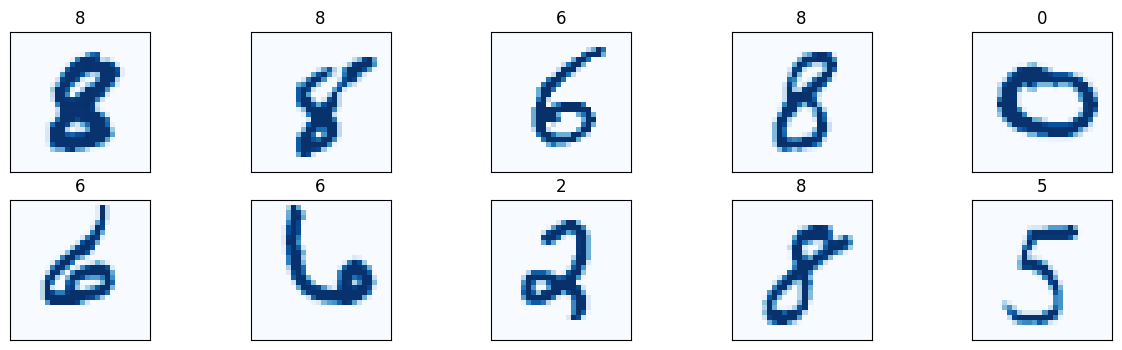

In [44]:
# visualizing data
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(15, 4))
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='Blues')
    ax.set_title(str(labels[idx].item()))

### Defining Model

In [61]:
from torch.nn.modules.flatten import Flatten
from torch.nn.modules.activation import ReLU
class Custom_CNN(nn.Module):
  def __init__(self):
     super().__init__()

     self.net = nn.Sequential(
         #C1
         nn.Conv2d(1, 32, 3),
         nn.ReLU(),
         nn.MaxPool2d(2),

         #C2
         nn.Conv2d(32, 16, 3),
         nn.ReLU(),
         nn.MaxPool2d(2),

         #C3
        #  nn.Conv2d(32, 64, 3),
        #  nn.ReLU(),
        #  nn.MaxPool2d(2),

         #F4
         nn.Flatten(),
         nn.Linear(16 * 5 * 5, 64),
         nn.ReLU(),

         #Output Layer
         nn.Linear(64, 10)
     )

  def forward(self, x):
    return self.net(x)

In [12]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [67]:
custom_cnn = Custom_CNN().to(device)

print(f"Number of Parameters: {count_trainable_parameters(custom_cnn)}")

Number of Parameters: 31258


In [68]:
print(custom_cnn)

Custom_CNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=400, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)


### Utility Functions

In [48]:
def train_model(model, criterion, optimizer, train_loss_curve, val_loss_curve):

  for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch}")
    train_loss = 0
    val_loss = 0

    # TRAINING
    model.train()

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      # clear prev grads
      optimizer.zero_grad()

      # forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      # backward pass
      loss.backward()

      # update weights
      optimizer.step()
      train_loss += loss.item() * images.size(0)

    # avg train loss
    epoch_train_loss = train_loss/len(train_loader)

    # for plotting loss
    train_loss_curve.append(epoch_train_loss)

    # VALIDATION
    with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)

          val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_loss_curve.append(epoch_val_loss)

    print(f"Train Loss: {epoch_train_loss}, Val Loss: {epoch_val_loss}\n")



In [40]:
def evaluate_model(model):
  model.eval()

  correct_pred = 0
  total = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)

      _, pred = torch.max(outputs, 1)
      total += labels.size(0)
      correct_pred += (pred == labels).sum().item()


  print(f"Accuracy: {100 * correct_pred / total}")


### Model evaluation & Results

In [69]:
# hyperparameters
l_r = 0.001
optimizer = optim.Adam(custom_cnn.parameters(), lr=l_r)
criterion = nn.CrossEntropyLoss()

cudnn.benchmark = True #to treat it as benchmark testing for speeding up process

In [70]:
train_loss_curve = []
val_loss_curve = []
train_model(custom_cnn, criterion, optimizer, train_loss_curve, val_loss_curve)

Epoch 1
Train Loss: 2.5069644726182645, Val Loss: 0.0654789412424046

Epoch 2
Train Loss: 0.9112950901761651, Val Loss: 0.07512634623465904

Epoch 3
Train Loss: 0.6317590146408183, Val Loss: 0.055261154677078594

Epoch 4
Train Loss: 0.47199635831866665, Val Loss: 0.0684209802794309

Epoch 5
Train Loss: 0.37592095124935865, Val Loss: 0.05419577340621011

Epoch 6
Train Loss: 0.3007436658746913, Val Loss: 0.0577126541415461

Epoch 7
Train Loss: 0.2618448386290302, Val Loss: 0.0626791007436279

Epoch 8
Train Loss: 0.22705297872556204, Val Loss: 0.06243540265927771

Epoch 9
Train Loss: 0.2032309440360956, Val Loss: 0.07075540908296633

Epoch 10
Train Loss: 0.19697958421970096, Val Loss: 0.06462064756511227

Epoch 11
Train Loss: 0.16652239010782507, Val Loss: 0.0700165991930368

Epoch 12
Train Loss: 0.15216757849922405, Val Loss: 0.06405022735151135

Epoch 13
Train Loss: 0.1353213199115675, Val Loss: 0.0716441157944418

Epoch 14
Train Loss: 0.13342479912083893, Val Loss: 0.07377445684198101


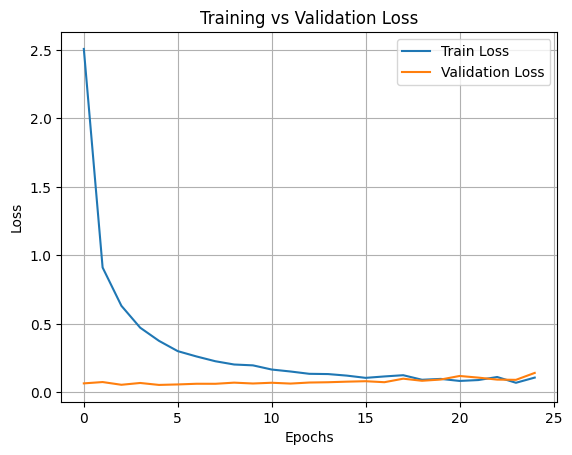

In [72]:
plt.plot(train_loss_curve, label='Train Loss')
plt.plot(val_loss_curve, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()

plt.show()

### Saving Model

In [73]:
torch.save(custom_cnn.state_dict(), 'custom_cnn_weights.pth')